In [ ]:
import pandas as pd

df = pd.read_csv("../data/cleaned_data.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# FEATURE ENGINEERING

In [4]:

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2


# RFM SEGMENTATION

In [7]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()
#rfm.describe()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [8]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)
rfm.head()
  

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,6
12347.0,2,182,4310.00,4,4,4,12
12348.0,75,31,1797.24,2,2,4,8
12349.0,19,73,1757.55,3,3,4,10
12350.0,310,17,334.40,1,1,2,4


# TIME SERIES DATA 

In [10]:
time_series = df.groupby('InvoiceDate').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).reset_index()

time_series.head()

,InvoiceDate,Quantity,TotalPrice
0,2010-12-01 08:26:00,40,139.12
1,2010-12-01 08:28:00,12,22.20
2,2010-12-01 08:34:00,98,348.78
3,2010-12-01 08:35:00,3,17.85
4,2010-12-01 08:45:00,449,855.86


In [11]:
#adding exact time features

time_series['day_of_week'] = time_series['InvoiceDate'].dt.dayofweek
time_series['month'] = time_series['InvoiceDate'].dt.month

In [12]:
#lag and rolling features 

time_series['lag_7'] = time_series['Quantity'].shift(7)
time_series['rolling_mean_7'] = time_series['Quantity'].rolling(7).mean()

In [13]:
time_series= time_series.dropna()

In [14]:
# DEMAND FORECASTING

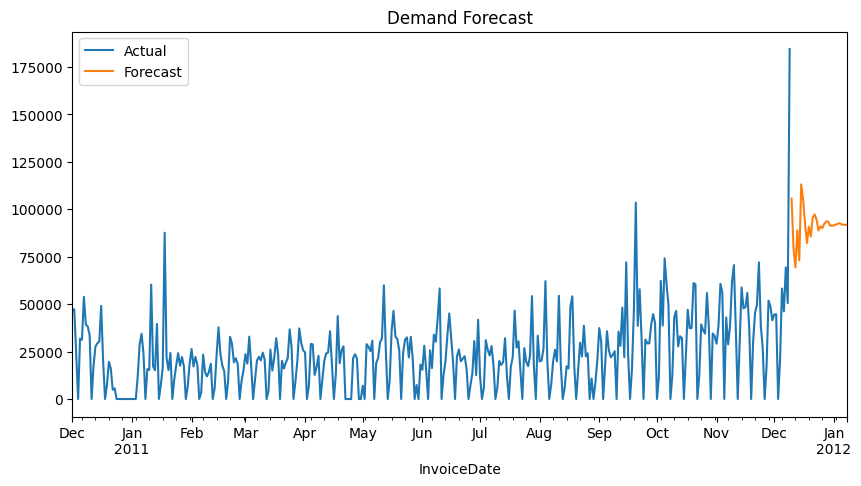

In [17]:
#import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

ts = df.groupby('InvoiceDate')['TotalPrice'].sum().resample('D').sum()
ts = ts.fillna(0)

model = ARIMA(ts, order=(5,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
ts.plot(label="Actual")
forecast.plot(label="Forecast")
plt.legend()
plt.title("Demand Forecast")
plt.show()

In [18]:
# CHURN MODEL

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

# Create the 'models' directory if it doesn't exist
os.makedirs("models", exist_ok=True)

rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "models/churn_model.pkl")

print("Churn Model Accuracy:", model.score(X_test, y_test))

Churn Model Accuracy: 1.0


In [20]:
# INVENTORY ANALYSIS

In [21]:
product_sales = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)

fast_moving = product_sales.head(10)
slow_moving = product_sales.tail(10)

print("Fast Moving Products:\n", fast_moving)
print("Slow Moving Products:\n", slow_moving)

Fast Moving Products:
 StockCode
23843     80995
23166     77916
84077     54415
22197     49183
85099B    46181
85123A    36782
84879     35362
21212     33693
23084     27202
22492     26076
Name: Quantity, dtype: int64
Slow Moving Products:
 StockCode
21310     1
90152B    1
85170A    1
21839     1
22146     1
90152C    1
21895     1
21414     1
47503J    1
47579     1
Name: Quantity, dtype: int64


In [22]:
# FINAL OUTPUTS

In [25]:
rfm.to_csv("../data/cleaned_data.csv")
forecast.to_csv("../data/forecast.csv")

# Save Time Series
time_series.to_csv("/time_series.csv", index=False)

print("\nProject Completed Successfully!")


Project Completed Successfully!
